In [340]:
#merging AWcustomers.csv and AWsales.csv using customerid as a primary key into a single dataset
import pandas as pd
customers = pd.read_csv('AWcustomers.csv')
sales = pd.read_csv('AWsales.csv')
merged_data = pd.merge(customers, sales, on='CustomerID')
merged_data.to_csv('AWmerged.csv', index=False)


In [341]:
#finding the total number of rows and columns in the merged dataset
rows, columns = merged_data.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 18361
Number of columns: 26


In [342]:
#CHECKING COLUMNS WITH NULL VALUES
null_columns = merged_data.columns[merged_data.isnull().any()]
print(null_columns)

Index(['Title', 'MiddleName', 'Suffix', 'AddressLine2'], dtype='object')


In [343]:
#checking the column with less than 50% null values
null_counts=merged_data.isnull().sum()
threshold=len(merged_data)*0.5
print("coulmn having less than 50% null values:")
print(null_counts[null_counts<threshold])

coulmn having less than 50% null values:
CustomerID                 0
FirstName                  0
MiddleName              7789
LastName                   0
AddressLine1               0
City                       0
StateProvinceName          0
CountryRegionName          0
PostalCode                 0
PhoneNumber                0
BirthDate                  0
Education                  0
Occupation                 0
Gender                     0
MaritalStatus              0
HomeOwnerFlag              0
NumberCarsOwned            0
NumberChildrenAtHome       0
TotalChildren              0
YearlyIncome               0
LastUpdated                0
BikeBuyer                  0
AvgMonthSpend              0
dtype: int64


In [344]:
#number of unique values for the middlename column
unique_middlenames=merged_data['MiddleName'].unique()

In [345]:
#replacing the null values of the middlename column with mode of middlenames
mode_middlename=merged_data['MiddleName'].mode()[0]
merged_data.fillna({"MiddleName":mode_middlename},inplace=True)

In [346]:
#remove irrelevant columns: first name last name middle name address line 1 address line 2 phone number,educationMaritalStatus,HomeOwnerFlag,NumberCarsOwned
# NumberChildrenAtHome,TotalChildren,YearlyIncome,LastUpdated,BikeBuyer,AvgMonthSpend
merged_data.drop(columns=['FirstName','LastName','MiddleName','AddressLine1','AddressLine2','PhoneNumber','MaritalStatus','HomeOwnerFlag','NumberChildrenAtHome','TotalChildren'],inplace=True)
#calculating remaining columns count
remainingcolumns=len(merged_data.columns)
print(f"Number of remaining columns: {remainingcolumns}")

Number of remaining columns: 16


In [347]:
#finding number of categorical columns
categoricalcolumns=merged_data.select_dtypes(include=['object']).columns
categoricallength=len(categoricalcolumns)
print(f"Number of categorical columns: {categoricallength}")

Number of categorical columns: 11


In [348]:
#except date of birth convert all categorical columns to numerical using one hot encoding
merged_data=pd.get_dummies(merged_data,columns=categoricalcolumns.drop('BirthDate'))
print("Categorical columns converted to numerical using one hot encoding")


Categorical columns converted to numerical using one hot encoding


In [349]:
#now number of columns which are categorical
categoricalnewct=merged_data.select_dtypes(include=['object']).columns
print({len(categoricalnewct)})
#number of total columns
totalcols=len(merged_data.columns)
print(totalcols)

{1}
678


In [350]:
from datetime import datetime
import pandas as pd
currentyear = datetime.now().year
merged_data['Age'] = currentyear - pd.to_datetime(merged_data['BirthDate'],errors='coerce').dt.year
print(merged_data[['BirthDate', 'Age']].head())
print(merged_data['Age'].dtype)


    BirthDate  Age
0  1987-11-13   39
1  1972-07-21   54
2  1985-11-09   41
3  1977-10-18   49
4  1975-02-05   51
int32


In [351]:
merged_data.drop(columns=['BirthDate'], inplace=True)
from sklearn.preprocessing import MinMaxScaler
numerical_cols = merged_data.select_dtypes(include=['int64', 'float64']).columns

# exclude Age safely
numerical_cols = [col for col in numerical_cols if col != 'Age']

scaler = MinMaxScaler()
merged_data[numerical_cols] = scaler.fit_transform(merged_data[numerical_cols])


Text(0.5, 1.0, 'Correlation Matrix')

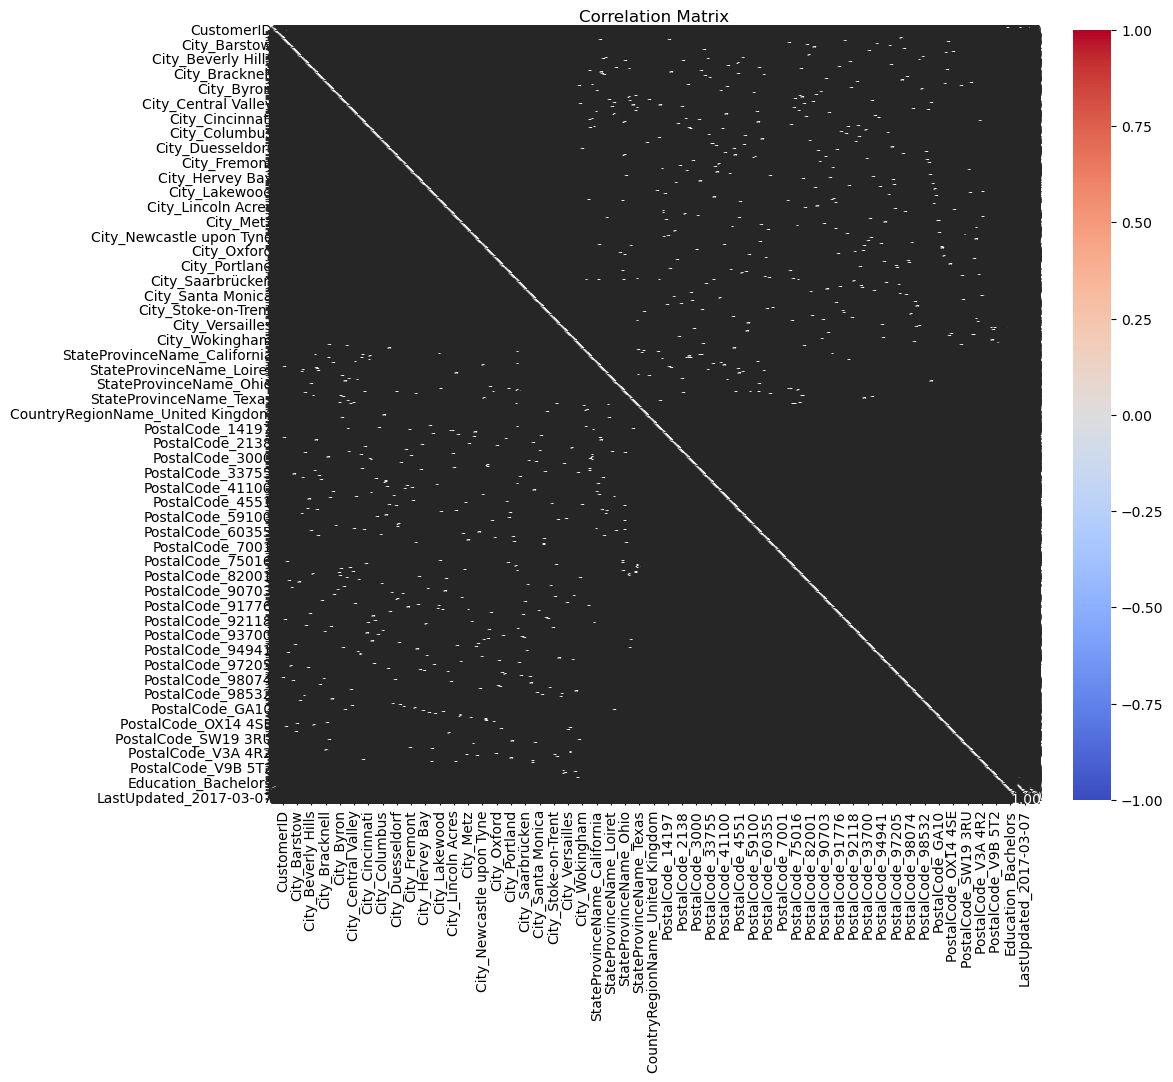

In [352]:
#finding correlation between all columns using graphs
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix = merged_data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix") 